In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd


In [2]:
import sys
import os
import time
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

# testing if we correctly put in module 3 into file ... 

In [3]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [4]:
# Set environment variables
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# Create new session with explicit local binding
spark = SparkSession.builder \
    .appName("EEG_Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .master("local[*]") \
    .getOrCreate()

print("New Spark session created successfully")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/05 11:44:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


New Spark session created successfully


In [5]:
spark = SparkSession.builder.appName("MyApp").getOrCreate()


25/04/05 11:44:36 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [6]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema


# from feature_extraction

In [7]:
# preprocess_sets.setProjectRootDir()
subject_df = load_subjects_df(spark)


In [8]:
#setting up the dependencies in the spark context

In [9]:
ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

In [10]:
sc = spark.sparkContext

In [11]:

# Add all necessary modules
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context


In [12]:
#testing a single person

In [13]:
%%time
result = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
result.show()

/Users/admin/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
function ran                                                        (0 + 1) / 1]
Processing subject sub-001
processSub sub-001
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Got 398 epochs for sub-001
<class 'mne.epochs.Epochs'>
Epoch 0
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Epoch 1
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Total rows collected: 37810
Returning DataFrame with 37810 rows
Column names from schema: ['SubjectID', 'EpochID', 'WaveBand', 'Electrode', 'Power']
4.084625959396362
                                                                                

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-001|   ep-0|   Delta|      Fp1| 0.08257892642542033|
|  sub-001|   ep-0|   Theta|      Fp1|0.005611645685714301|
|  sub-001|   ep-0|   Alpha|      Fp1|0.001143220388171...|
|  sub-001|   ep-0|    Beta|      Fp1|1.958040080323613...|
|  sub-001|   ep-0|   Total|      Fp1|0.011235955056179773|
|  sub-001|   ep-0|   Delta|      Fp2| 0.08389220643958975|
|  sub-001|   ep-0|   Theta|      Fp2|0.004672355992737972|
|  sub-001|   ep-0|   Alpha|      Fp2|9.638188967593915E-4|
|  sub-001|   ep-0|    Beta|      Fp2|1.768820461211869...|
|  sub-001|   ep-0|   Total|      Fp2|0.011235955056179771|
|  sub-001|   ep-0|   Delta|       F3| 0.08212274846138015|
|  sub-001|   ep-0|   Theta|       F3|0.005595318986261473|
|  sub-001|   ep-0|   Alpha|       F3|0.001112336388491...|
|  sub-001|   ep-0|    Beta|       F3|2.

In [14]:
%%time
# Start both groups processing (lazy evaluation means these won't execute yet)
result_group_a = (
    subject_df
    .filter(subject_df.Group == "A")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

result_group_c = (
    subject_df
    .filter(subject_df.Group == "C")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

# Force execution of both by calling an action on each
# This launches both jobs in parallel
from pyspark.sql import functions as F

# Use persist to cache the results in memory
result_group_a = result_group_a.persist()
result_group_c = result_group_c.persist()

# Trigger execution with actions
count_a = result_group_a.count()
count_c = result_group_c.count()

print(f"Processed {count_a} records for Alzheimer's group")
print(f"Processed {count_c} records for Control group")

function ran==========================================>        (168 + 10) / 200]
Processing subject sub-018
processSub sub-018
function ran
Processing subject sub-012
processSub sub-012
function ran
Processing subject sub-021
processSub sub-021
function ran
Processing subject sub-001
processSub sub-001
function ran
Processing subject sub-002
processSub sub-002
function ran
Processing subject sub-016
processSub sub-016
function ran
Processing subject sub-011
processSub sub-011
function ran
Processing subject sub-029
processSub sub-029
function ran
Processing subject sub-020
processSub sub-020
function ran
Processing subject sub-017
processSub sub-017
subPath sub-021
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-021/eeg/sub-021_task-eyesclosed_eeg.set
subPath sub-012
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
subPath sub-011
Pa

Processed 1856870 records for Alzheimer's group
Processed 1543465 records for Control group
CPU times: user 323 ms, sys: 194 ms, total: 518 ms
Wall time: 4min 19s


In [57]:
result_group_a.show

<bound method DataFrame.show of DataFrame[SubjectID: string, EpochID: string, WaveBand: string, Electrode: string, Power: float]>

In [58]:
result_group_a.show(30)

+---------+-------+--------+---------+------------+
|SubjectID|EpochID|WaveBand|Electrode|       Power|
+---------+-------+--------+---------+------------+
|  sub-020|   ep-0|   Delta|      Fp1|  0.07823379|
|  sub-020|   ep-0|   Theta|      Fp1|0.0065223426|
|  sub-020|   ep-0|   Alpha|      Fp1|0.0035932148|
|  sub-020|   ep-0|    Beta|      Fp1|3.3410414E-4|
|  sub-020|   ep-0|   Total|      Fp1| 0.011235955|
|  sub-020|   ep-0|   Delta|      Fp2|  0.07762735|
|  sub-020|   ep-0|   Theta|      Fp2| 0.006942656|
|  sub-020|   ep-0|   Alpha|      Fp2|0.0031151567|
|  sub-020|   ep-0|    Beta|      Fp2|4.7047035E-4|
|  sub-020|   ep-0|   Total|      Fp2| 0.011235955|
|  sub-020|   ep-0|   Delta|       F3|  0.08036582|
|  sub-020|   ep-0|   Theta|       F3| 0.005188234|
|  sub-020|   ep-0|   Alpha|       F3|0.0023103736|
|  sub-020|   ep-0|    Beta|       F3|4.8134642E-4|
|  sub-020|   ep-0|   Total|       F3| 0.011235955|
|  sub-020|   ep-0|   Delta|       F4| 0.070942834|
|  sub-020| 

In [59]:
try:
    result = result_group_a[(result_group_a['SubjectID'] == 'sub-001') & 
                     (result_group_a['Electrode'] == 'Fp1') & 
                     (result_group_a['WaveBand'] == 'Delta')]['Power'].iloc[0]
    print(f"Type: {type(result)}")
    print(f"Value: {result}")
except Exception as e:
    print(f"Method 1 error: {e}")

Type: <class 'pyspark.sql.column.Column'>
Value: Column<'Power[iloc][0]'>


# attempting pyspark land

In [60]:
from pyspark.sql.functions import col

In [61]:
# Just look directly at the UDTF output for sub-020, F3, Total
result_group_a.filter(
    (col("SubjectID") == "sub-020") &
    (col("Electrode") == "F3") &
    (col("WaveBand") == "Total")
).show()

+---------+-------+--------+---------+-----------+
|SubjectID|EpochID|WaveBand|Electrode|      Power|
+---------+-------+--------+---------+-----------+
|  sub-020|   ep-0|   Total|       F3|0.011235955|
|  sub-020|   ep-1|   Total|       F3|0.011235955|
|  sub-020|   ep-2|   Total|       F3|0.011235955|
|  sub-020|   ep-3|   Total|       F3|0.011235955|
|  sub-020|   ep-4|   Total|       F3|0.011235955|
|  sub-020|   ep-5|   Total|       F3|0.011235955|
|  sub-020|   ep-6|   Total|       F3|0.011235955|
|  sub-020|   ep-7|   Total|       F3|0.011235955|
|  sub-020|   ep-8|   Total|       F3|0.011235955|
|  sub-020|   ep-9|   Total|       F3|0.011235955|
|  sub-020|  ep-10|   Total|       F3|0.011235955|
|  sub-020|  ep-11|   Total|       F3|0.011235955|
|  sub-020|  ep-12|   Total|       F3|0.011235955|
|  sub-020|  ep-13|   Total|       F3|0.011235955|
|  sub-020|  ep-14|   Total|       F3|0.011235955|
|  sub-020|  ep-15|   Total|       F3|0.011235955|
|  sub-020|  ep-16|   Total|   

In [69]:
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev, broadcast
from pyspark.sql.types import FloatType

# Step 1: Convert Power to float32
result_group_a = result_group_a.withColumn("Power", col("Power").cast(FloatType()))
result_group_c = result_group_c.withColumn("Power", col("Power").cast(FloatType()))



In [70]:
# Step 2: Compute mean and std from result_group_a only
norm_stats = result_group_a.groupBy("Electrode", "WaveBand").agg(
    _mean("Power").alias("mean_power"),
    _stddev("Power").alias("std_power")
)


In [71]:
# Step 3: Broadcast join stats to both result_group_a and result_group_c
result_group_a_norm = result_group_a.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)

result_group_c_norm = result_group_c.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)

In [72]:
from pyspark.sql.functions import when

In [73]:
result_group_a_norm = result_group_a_norm.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0) #this otherwise sets std to 1 and since std is 0 mean_power - power = 0
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0)
)

In [74]:
# Step 5 (optional): Drop extra columns
result_group_a_norm = result_group_a_norm.drop("mean_power", "std_power")
result_group_c_norm = result_group_c_norm.drop("mean_power", "std_power")

In [75]:
# Just look directly at the UDTF output for sub-020, F3, Total
result_group_a_norm.filter(
    (col("SubjectID") == "sub-020") &
    (col("Electrode") == "F3") &
    (col("WaveBand") == "Total")
).show()

+---------+--------+---------+-------+-----+
|Electrode|WaveBand|SubjectID|EpochID|Power|
+---------+--------+---------+-------+-----+
|       F3|   Total|  sub-020|   ep-0|  0.0|
|       F3|   Total|  sub-020|   ep-1|  0.0|
|       F3|   Total|  sub-020|   ep-2|  0.0|
|       F3|   Total|  sub-020|   ep-3|  0.0|
|       F3|   Total|  sub-020|   ep-4|  0.0|
|       F3|   Total|  sub-020|   ep-5|  0.0|
|       F3|   Total|  sub-020|   ep-6|  0.0|
|       F3|   Total|  sub-020|   ep-7|  0.0|
|       F3|   Total|  sub-020|   ep-8|  0.0|
|       F3|   Total|  sub-020|   ep-9|  0.0|
|       F3|   Total|  sub-020|  ep-10|  0.0|
|       F3|   Total|  sub-020|  ep-11|  0.0|
|       F3|   Total|  sub-020|  ep-12|  0.0|
|       F3|   Total|  sub-020|  ep-13|  0.0|
|       F3|   Total|  sub-020|  ep-14|  0.0|
|       F3|   Total|  sub-020|  ep-15|  0.0|
|       F3|   Total|  sub-020|  ep-16|  0.0|
|       F3|   Total|  sub-020|  ep-17|  0.0|
|       F3|   Total|  sub-020|  ep-18|  0.0|
|       F3

In [76]:
# PCA time 

In [77]:
from pyspark.sql.functions import concat_ws

result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)



In [78]:
result_group_a_norm.filter(col("WaveBand") == "Total").select("Electrode", "WaveBand").distinct().show()


+---------+--------+
|Electrode|WaveBand|
+---------+--------+
|       T5|   Total|
|       P3|   Total|
|       F4|   Total|
|       T6|   Total|
|       O2|   Total|
|       T4|   Total|
|       F8|   Total|
|       T3|   Total|
|       O1|   Total|
|       Fz|   Total|
|       Cz|   Total|
|       C3|   Total|
|       F7|   Total|
|       Pz|   Total|
|       P4|   Total|
|      Fp2|   Total|
|       F3|   Total|
|       C4|   Total|
|      Fp1|   Total|
+---------+--------+



In [79]:
# result_group_a_norm.filter((col("subjectID" == "sub-001")) & (col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()
result_group_a_norm.filter((col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()


+---------+--------+---------+-------+-----+------------------+
|Electrode|WaveBand|SubjectID|EpochID|Power|Electrode_WaveBand|
+---------+--------+---------+-------+-----+------------------+
|       F3|   Total|  sub-020|   ep-0|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-1|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-2|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-3|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-4|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-5|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-6|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-7|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-8|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-9|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-10|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-11|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-12|  

In [80]:
pivot_keys = [row["Electrode_WaveBand"] for row in result_group_a_norm.select("Electrode_WaveBand").distinct().collect()]

In [81]:
from pyspark.sql.functions import concat_ws

# Just in case it's not there yet
result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)


# Recollect unique combinations
pivot_keys = [row["Electrode_WaveBand"] for row in result_group_a_norm.select("Electrode_WaveBand").distinct().collect()]
pivot_keys = sorted(pivot_keys)

In [82]:
print([key for key in pivot_keys if "Total" in key])


['C3_Total', 'C4_Total', 'Cz_Total', 'F3_Total', 'F4_Total', 'F7_Total', 'F8_Total', 'Fp1_Total', 'Fp2_Total', 'Fz_Total', 'O1_Total', 'O2_Total', 'P3_Total', 'P4_Total', 'Pz_Total', 'T3_Total', 'T4_Total', 'T5_Total', 'T6_Total']


In [83]:
features_df = (
    result_group_a_norm
    .groupBy("SubjectID")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})  # Or "avg", depending on your use case
)

In [84]:
features_df.head()

25/04/05 12:08:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Row(SubjectID='sub-033', C3_Alpha=-0.366072338365684, C3_Beta=-0.3739255615818644, C3_Delta=0.3451326619224264, C3_Theta=-0.19772819767476607, C3_Total=0.0, C4_Alpha=-0.5827885842733205, C4_Beta=-0.24206354338506472, C4_Delta=0.4545619073760804, C4_Theta=-0.35525386514991614, C4_Total=0.0, Cz_Alpha=-0.5653609075729761, Cz_Beta=-0.469536618568523, Cz_Delta=0.4703553956058822, Cz_Theta=-0.2858423735924688, Cz_Total=0.0, F3_Alpha=-0.17154391714953296, F3_Beta=1.301948992262222, F3_Delta=-0.4450148711606287, F3_Theta=0.0477625921370626, F3_Total=0.0, F4_Alpha=-0.3836673004479627, F4_Beta=-0.11474923229378396, F4_Delta=0.2555756663725288, F4_Theta=-0.17413824607158424, F4_Total=0.0, F7_Alpha=0.5345500774944755, F7_Beta=-0.31315759641055263, F7_Delta=0.09652402686314823, F7_Theta=-0.1963099579171413, F7_Total=0.0, F8_Alpha=0.08834219674159094, F8_Beta=-0.3123153435268461, F8_Delta=0.3030625942731104, F8_Theta=-0.3560740625464076, F8_Total=0.0, Fp1_Alpha=-0.20628716148213744, Fp1_Beta=0.60626

In [89]:
from pyspark.sql.functions import col, sum

In [93]:
# Print only the combos with missing values
null_counts = df.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])

NameError: name 'df' is not defined

In [86]:
sorted_nulls = sorted(null_counts_dict.items(), key=lambda x: x[1], reverse=True)
for col_name, count in sorted_nulls:
    if count > 0:
        print(f"{col_name}: {count} missing")


NameError: name 'null_counts_dict' is not defined

In [94]:
from pyspark.ml.feature import VectorAssembler

# remove 'SubjectID' from the feature list
feature_cols = [col for col in features_df.columns if col != "SubjectID"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(features_df).select("SubjectID", "features")

In [137]:
from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)

In [138]:
explained_variance = pca_model.explainedVariance.toArray()

In [139]:
explained_variance

array([0.59265197, 0.13683198, 0.08035519, 0.0403049 , 0.01718616,
       0.01234244, 0.01108178, 0.00988992, 0.00850305, 0.00820459,
       0.00678157, 0.00607204, 0.00516425, 0.00490389, 0.00457563,
       0.00381469, 0.00333946, 0.00321859, 0.0030672 , 0.0029599 ])

In [140]:
explained_variance[0] + explained_variance[1]

np.float64(0.7294839566271483)

In [142]:
explained_variance[:8].sum()

np.float64(0.9006443510484327)

In [146]:
explained_variance[:12].sum()

np.float64(0.9302056036735993)

In [144]:
explained_variance[:17].sum()

np.float64(0.9520035245914317)

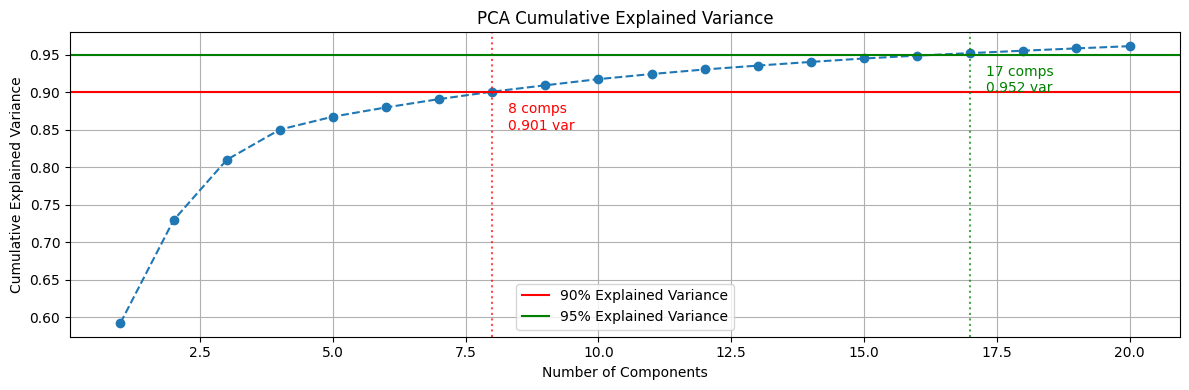

In [147]:
import matplotlib.pyplot as plt
import numpy as np

# Get the variance values from PySpark
explained_variance = pca_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

# Find component index where thresholds are reached
thresholds = [0.90, 0.95]
threshold_indices = [np.argmax(cumulative_variance >= t) for t in thresholds]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw horizontal and vertical lines at thresholds
colors = ['r', 'g']
for idx, t in zip(threshold_indices, thresholds):
    comp_number = idx + 1
    cum_var = cumulative_variance[idx]

    # Horizontal line
    plt.axhline(y=t, color=colors[thresholds.index(t)], linestyle='-', label=f'{int(t*100)}% Explained Variance')
    # Vertical line
    plt.axvline(x=comp_number, color=colors[thresholds.index(t)], linestyle=':', alpha=0.7)
    # Annotation
    plt.text(comp_number + 0.3, t - 0.05, f'{comp_number} comps\n{cum_var:.3f} var', color=colors[thresholds.index(t)])

# Labels & Legend
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Doing pyspark ML 

In [171]:
from pyspark.sql.functions import lit

# Add label column (0 = Group A, 1 = Group C)
result_group_a_norm = result_group_a_norm.withColumn("label", lit(1))
result_group_c_norm = result_group_c_norm.withColumn("label", lit(0))

print("Columns in result_group_a_norm:")
print(result_group_a_norm.columns)

print("\nColumns in result_group_c_norm:")
print(result_group_c_norm.columns)


Columns in result_group_a_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']

Columns in result_group_c_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']


In [172]:
# Combine into one dataset
full_df = result_group_a_norm.union(result_group_c_norm)



In [173]:
from pyspark.sql.functions import concat_ws
from pyspark.ml.feature import VectorAssembler

# Create unique feature key for pivot
full_df = full_df.withColumn("Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand"))


In [174]:
# Get all unique feature keys
pivot_keys = [row["Electrode_WaveBand"] for row in full_df.select("Electrode_WaveBand").distinct().collect()]

# Pivot into wide format
features_df = (
    full_df.groupBy("SubjectID", "EpochID", "label")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})
    .fillna(0.0)
)


In [175]:
feature_cols = [c for c in features_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "label", "features")


In [176]:
from pyspark.ml.feature import PCA

# Try a high number first (e.g., all features)
k_max = len(feature_cols)
pca_model = PCA(k=k_max, inputCol="features", outputCol="pca_features").fit(assembled_df)

# Get explained variance and find smallest k with >= 0.95 cumulative
import numpy as np

vairance_goal = 0.95

explained_variance = np.cumsum(pca_model.explainedVariance.toArray())
k_val = np.argmax(explained_variance >= vairance_goal) + 1  # +1 because index starts at 0
print(f"Using top {k_val} components to explain {vairance_goal}% variance")

Using top 17 components to explain 0.95% variance


In [177]:
pca = PCA(k=k_val, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)


In [178]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Turn vector into individual PC columns
pca_result = pca_result.withColumn("pca_array", vector_to_array("pca_features"))

# Select label + principal components
for i in range(k_val):
    pca_result = pca_result.withColumn(f"PC{i+1}", col("pca_array")[i])

# Final dataframe with PCs
full_df = pca_result.select("SubjectID", "EpochID", "label", *[f"PC{i+1}" for i in range(k_val)])


In [179]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [col for col in full_df.columns if col.startswith("PC")]
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
assembled_df = assembler.transform(full_df).select("features", "label")

In [180]:
# Step 1: Get distinct subject IDs from each group
group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

# Step 2: Get the last 3 subjects from each group for testing
test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Step 3: Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))


In [181]:
test_df.head()

Row(SubjectID='sub-034', EpochID='ep-520', label=1, PC1=3.9741088525349366, PC2=1.3922212555120952, PC3=-0.7332435692395173, PC4=0.838567084205097, PC5=0.6868835941830943, PC6=-0.18727588195209563, PC7=-0.019948287898389698, PC8=0.41825410068645, PC9=0.08594672939239473, PC10=-0.11636906397455822, PC11=0.03520911700293005, PC12=0.3603201807704416, PC13=0.4873955092911777, PC14=0.1938562028093585, PC15=-0.04742307108268983, PC16=0.09007715715772477, PC17=0.005278049263206346)

In [182]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df = assembler.transform(train_df).select("features", "label")
test_df = assembler.transform(test_df).select("features", "label")

from pyspark.sql.types import IntegerType
train_df = train_df.withColumn("label", train_df["label"].cast(IntegerType()))
test_df = test_df.withColumn("label", test_df["label"].cast(IntegerType()))

In [183]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(pca_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df)
mlp_preds = mlp_model.transform(test_df)


[Stage 70582:===================>                                  (4 + 7) / 11]

In [184]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
mlp_auc = evaluator.evaluate(mlp_preds)

print("MLP AUC:", mlp_auc)

[Stage 70597:========================>                             (5 + 6) / 11]

MLP AUC: 0.8293841728939303


In [185]:
preds_pd = mlp_preds.select("prediction", "label").toPandas()

In [186]:
from sklearn.metrics import classification_report, accuracy_score

print("Neural Network accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))


Neural Network accuracy: 0.743762841209275
              precision    recall  f1-score   support

     Control       0.76      0.70      0.73      1691
 Alzheimer's       0.73      0.79      0.76      1716

    accuracy                           0.74      3407
   macro avg       0.75      0.74      0.74      3407
weighted avg       0.75      0.74      0.74      3407



# Note for Tomorrow: 
was on this chat yesterday : result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)
 ... so need to figure this out , i pased twice , i saved, i think the save before 1:30 should be good 

In [102]:
from pyspark.sql.functions import concat_ws
from pyspark.ml.feature import VectorAssembler

# Create unique feature key: Electrode_WaveBand
full_df = full_df.withColumn("Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand"))

# Get all feature names
pivot_keys = [row["Electrode_WaveBand"] for row in full_df.select("Electrode_WaveBand").distinct().collect()]

# Pivot
features_df = (
    full_df.groupBy("SubjectID", "EpochID", "label")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})
    .fillna(0.0)  # Fill missing combos with 0
)

# Assemble into vector
feature_cols = [c for c in features_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(features_df).select("features", "label")


In [103]:
train_df, test_df = assembled_df.randomSplit([0.8, 0.2], seed=42)


In [104]:
from pyspark.sql.types import IntegerType

train_df = train_df.withColumn("label", train_df["label"].cast(IntegerType()))
test_df = test_df.withColumn("label", test_df["label"].cast(IntegerType()))


In [105]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
# need remove/ignore forst column/label because strings
input_dim = len(feature_cols)
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],
    maxIter=10000,
    seed=42
)
mlp_model = mlp.fit(train_df)
mlp_preds = mlp_model.transform(test_df)


ERROR:root:KeyboardInterrupt while sending command.                             
Traceback (most recent call last):
  File "/Users/admin/neuro-venv/lib/python3.9/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/Users/admin/neuro-venv/lib/python3.9/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/socket.py", line 704, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 